## Assignment 10
#### Kit Illick
#### Computing and Research Methods for Climate Data Science
#### April 14, 2026

In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,  downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/home/cei2119/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


In [4]:
#1.1
ds = xr.open_dataset(fname)
ds

<xarray.Dataset> Size: 737MB
Dimensions:                      (lon: 360, time: 203, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

In [61]:
#1.2
for var in ds.data_vars:
    long_name = ds[var].attrs.get('long_name')
    print(f"{var}: {long_name}")

toa_sw_all_mon: Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon: Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon: Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon: Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon: Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon: Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon: Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon: Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon: Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon: Incoming Solar Flux, Monthly Means
cldarea_total_daynight_mon: Cloud Area Fraction, Monthly Means, Daytime-and-Nighttime conditions
cldpress_total_daynight_mon: Cloud Effective Pressure, Monthly Me

In [62]:
#2.1
ds_timemean = ds.mean(dim='time')
ds_timemean

<xarray.Dataset> Size: 4MB
Dimensions:                      (lon: 360, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 51.52 51.52 ... 78.93
    cldpress_total_daynight_mon  (lat, lon) float32 259kB 486.5 486.5 ... 766.9
    cldtemp_total_daynight_mon   (lat, lon) float32 259kB 225.2 225.2 ... 247.9
    cldtau_total_day_mon         (lat, lon) float32 259kB 4.158 4.158 ... 4.821

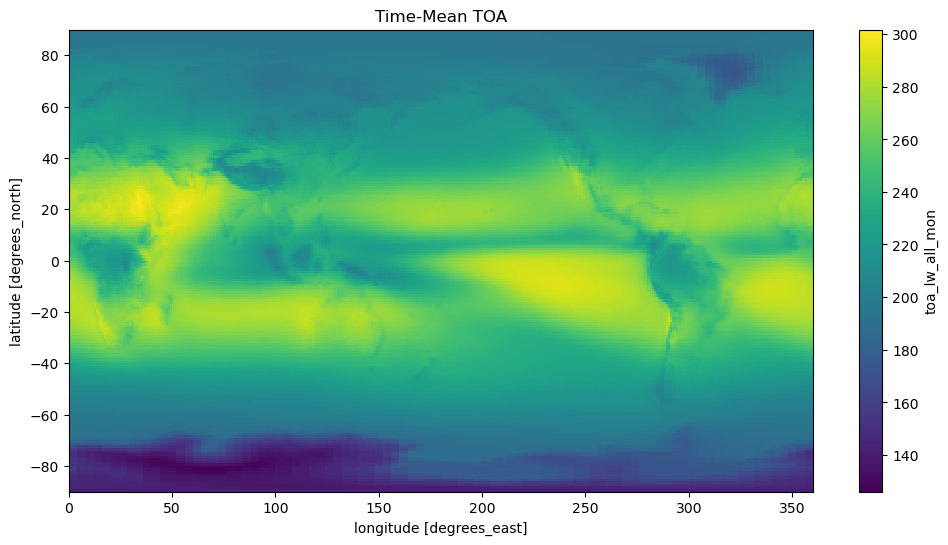

In [63]:
#2.2
# TOA Outgoing Longwave Radiation
ds_timemean['toa_lw_all_mon'].plot()
plt.title('Time-Mean TOA')
plt.show()

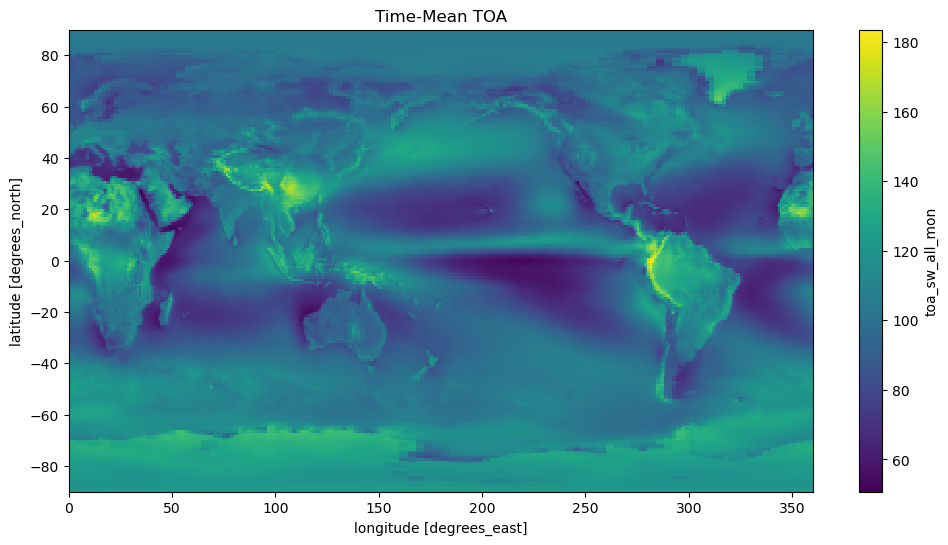

In [64]:
# TOA Outgoing Shortwave Radiation
ds_timemean['toa_sw_all_mon'].plot()
plt.title('Time-Mean TOA')
plt.show()

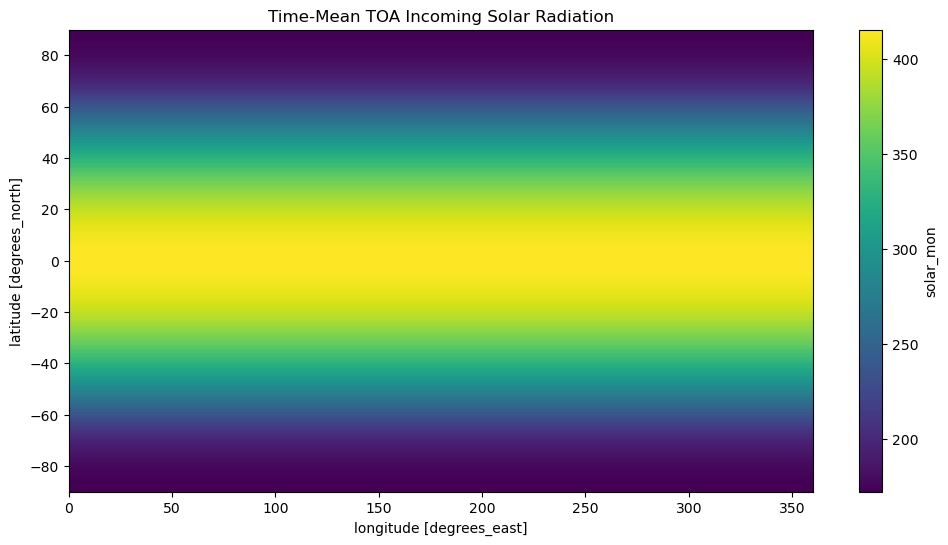

In [65]:
# TOA Incoming Solar Radiation
ds_timemean['solar_mon'].plot()
plt.title('Time-Mean TOA Incoming Solar Radiation')
plt.show()

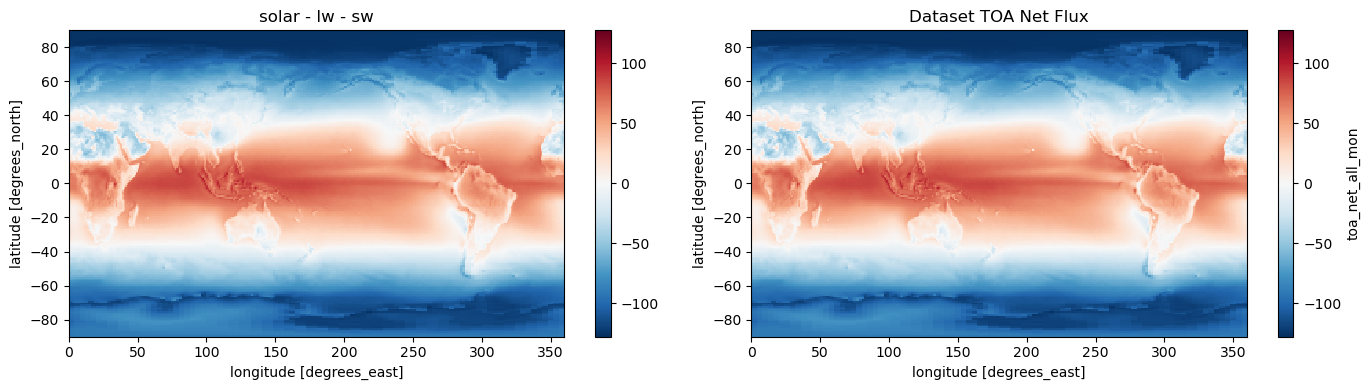

In [66]:
#2.3
toa_net_computed = ds_timemean['solar_mon'] - ds_timemean['toa_lw_all_mon'] - ds_timemean['toa_sw_all_mon']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
toa_net_computed.plot(ax=axes[0])
axes[0].set_title('solar - lw - sw')

ds_timemean['toa_net_all_mon'].plot(ax=axes[1])
axes[1].set_title('Dataset TOA Net Flux')

plt.tight_layout()
plt.show()

In [67]:
#3.1
toa_net_unweighted_mean = ds_timemean['toa_net_all_mon'].mean()
print('Unweighted global mean TOA net radiation:', float(toa_net_unweighted_mean), 'W/m^2')

Unweighted global mean TOA net radiation: -28.72901153564453 W/m^2


In [68]:
#3.2
#Convert to radians
weights = np.cos(ds['lat'] * np.pi / 180)
weights

<xarray.DataArray 'lat' (lat: 180)> Size: 720B
array([0.00872656, 0.02617699, 0.04361933, 0.06104851, 0.07845908,
       0.09584564, 0.11320312, 0.13052613, 0.14780948, 0.16504757,
       0.18223551, 0.19936782, 0.21643965, 0.2334453 , 0.25037998,
       0.26723838, 0.28401524, 0.30070582, 0.31730458, 0.3338068 ,
       0.35020736, 0.3665012 , 0.38268346, 0.398749  , 0.4146933 ,
       0.43051106, 0.44619778, 0.4617486 , 0.47715878, 0.49242356,
       0.50753826, 0.5224985 , 0.5372996 , 0.551937  , 0.5664062 ,
       0.58070296, 0.59482276, 0.60876137, 0.6225146 , 0.6360782 ,
       0.64944804, 0.66262   , 0.67559016, 0.68835455, 0.70090926,
       0.71325046, 0.72537434, 0.7372773 , 0.7489557 , 0.76040596,
       0.77162457, 0.78260815, 0.7933533 , 0.80385685, 0.8141155 ,
       0.8241262 , 0.8338858 , 0.8433914 , 0.85264015, 0.8616291 ,
       0.87035567, 0.8788171 , 0.8870108 , 0.89493436, 0.90258527,
       0.9099613 , 0.9170601 , 0.9238795 , 0.9304176 , 0.9366722 ,
       0.9426415 , 0.94832367, 0.95371693, 0.95881975, 0.96363044,
       0.96814764, 0.9723699 , 0.976296  , 0.9799247 , 0.9832549 ,
       0.9862856 , 0.9890159 , 0.9914449 , 0.9935719 , 0.9953962 ,
       0.9969173 , 0.9981348 , 0.99904823, 0.99965733, 0.9999619 ,
       0.9999619 , 0.99965733, 0.99904823, 0.9981348 , 0.9969173 ,
       0.9953962 , 0.9935719 , 0.9914449 , 0.9890159 , 0.9862856 ,
       0.9832549 , 0.9799247 , 0.976296  , 0.9723699 , 0.96814764,
       0.96363044, 0.95881975, 0.95371693, 0.94832367, 0.9426415 ,
       0.9366722 , 0.9304176 , 0.9238795 , 0.9170601 , 0.9099613 ,
       0.90258527, 0.89493436, 0.8870108 , 0.8788171 , 0.87035567,
       0.8616291 , 0.85264015, 0.8433914 , 0.8338858 , 0.8241262 ,
       0.8141155 , 0.80385685, 0.7933533 , 0.78260815, 0.77162457,
       0.76040596, 0.7489557 , 0.7372773 , 0.72537434, 0.71325046,
       0.70090926, 0.68835455, 0.67559016, 0.66262   , 0.64944804,
       0.6360782 , 0.6225146 , 0.60876137, 0.59482276, 0.58070296,
       0.5664062 , 0.551937  , 0.5372996 , 0.5224985 , 0.50753826,
       0.49242356, 0.47715878, 0.4617486 , 0.44619778, 0.43051106,
       0.4146933 , 0.398749  , 0.38268346, 0.3665012 , 0.35020736,
       0.3338068 , 0.31730458, 0.30070582, 0.28401524, 0.26723838,
       0.25037998, 0.2334453 , 0.21643965, 0.19936782, 0.18223551,
       0.16504757, 0.14780948, 0.13052613, 0.11320312, 0.09584564,
       0.07845908, 0.06104851, 0.04361933, 0.02617699, 0.00872656],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5

In [71]:
#3.3
toa_net_weighted_mean = ds_timemean['toa_net_all_mon'].weighted(weights).mean(dim=('lat', 'lon'))
print('Weighted global mean TOA net radiation:', float(toa_net_weighted_mean), 'W/m^2')
print('I dont think our calculation is precise enough to detect this, and i dont think there is enough data in this dataset to show this change')

Weighted global mean TOA net radiation: 0.8780879974365234 W/m^2
I dont think our calculation is precise enough to detect this, and i dont think there is enough data in this dataset to show this change


In [75]:
#3.4
solar_mean = ds_timemean['solar_mon'].weighted(weights).mean(dim=('lat', 'lon'))
lw_mean = ds_timemean['toa_lw_all_mon'].weighted(weights).mean(dim=('lat', 'lon'))
sw_mean = ds_timemean['toa_sw_all_mon'].weighted(weights).mean(dim=('lat', 'lon'))

print(f'Weighted mean incoming solar:        {float(solar_mean):} W/m^2  (infographic: 340.4)')
print(f'Weighted mean outgoing longwave:     {float(lw_mean):} W/m^2  (infographic: 238.5)')
print(f'Weighted mean outgoing shortwave:    {float(sw_mean):} W/m^2  (infographic: 99.9)')

Weighted mean incoming solar:        340.2835388183594 W/m^2  (infographic: 340.4)
Weighted mean outgoing longwave:     240.26669311523438 W/m^2  (infographic: 238.5)
Weighted mean outgoing shortwave:    99.13858795166016 W/m^2  (infographic: 99.9)


In [76]:
#4.1
R = 6371000  # Earth radius m

# Grid spacing in radians (1 degree)
dlat = np.deg2rad(1.0)
dlon = np.deg2rad(1.0)

# Area of each pixel
cos_lat = np.cos(np.deg2rad(ds['lat']))

# Use ones_like to broadcast to 2D (lat, lon)
area = R**2 * cos_lat * dlat * dlon * xr.ones_like(ds_timemean['toa_net_all_mon'])
area

<xarray.DataArray (lat: 180, lon: 360)> Size: 518kB
array([[1.07897926e+08, 1.07897926e+08, 1.07897926e+08, ...,
        1.07897926e+08, 1.07897926e+08, 1.07897926e+08],
       [3.23660522e+08, 3.23660522e+08, 3.23660522e+08, ...,
        3.23660522e+08, 3.23660522e+08, 3.23660522e+08],
       [5.39324525e+08, 5.39324525e+08, 5.39324525e+08, ...,
        5.39324525e+08, 5.39324525e+08, 5.39324525e+08],
       ...,
       [5.39324525e+08, 5.39324525e+08, 5.39324525e+08, ...,
        5.39324525e+08, 5.39324525e+08, 5.39324525e+08],
       [3.23660522e+08, 3.23660522e+08, 3.23660522e+08, ...,
        3.23660522e+08, 3.23660522e+08, 3.23660522e+08],
       [1.07897926e+08, 1.07897926e+08, 1.07897926e+08, ...,
        1.07897926e+08, 1.07897926e+08, 1.07897926e+08]])
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

In [79]:
earth_surface_area = 4 * np.pi * R**2
computed_area = float(area.sum())
print(f'Sum of pixel areas:         {computed_area:} m^2')
print(f'True Earth surface area:    {earth_surface_area:} m^2')
print(f'Difference:                 {abs(computed_area - earth_surface_area)/earth_surface_area*100:}%')

Sum of pixel areas:         510070949554564.94 m^2
True Earth surface area:    510064471909788.25 m^2
Difference:                 0.0012699658834174122%


In [80]:
#4.2
# Verify: sum of all pixels should equal Earth's surface area = 4 * pi * R^2
earth_surface_area = 4 * np.pi * R**2
computed_area = float(area.sum())
print(f'Sum of pixel areas:         {computed_area:} m^2')
print(f'True Earth surface area:    {earth_surface_area:} m^2')
print(f'Difference:                 {abs(computed_area - earth_surface_area)/earth_surface_area*100:}%')

Sum of pixel areas:         510070949554564.94 m^2
True Earth surface area:    510064471909788.25 m^2
Difference:                 0.0012699658834174122%


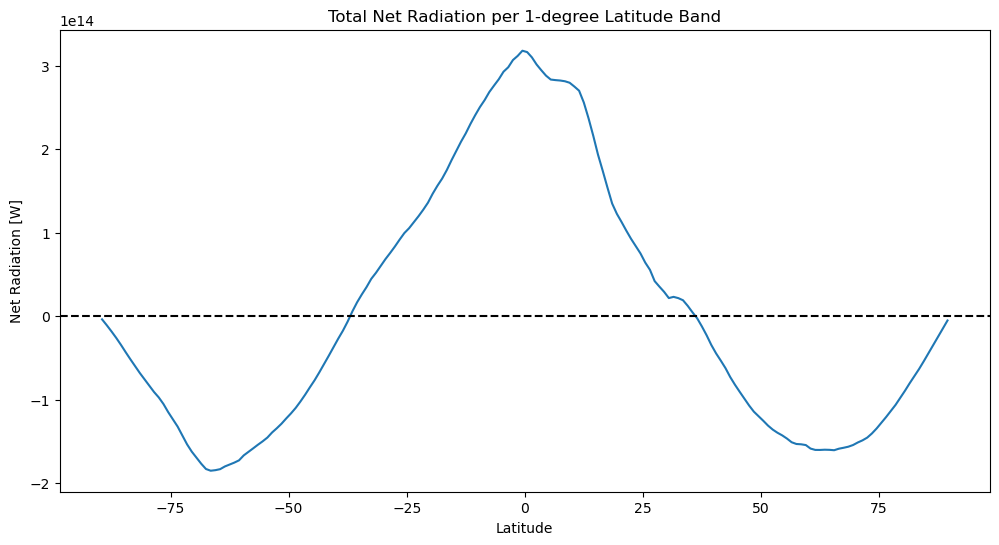

In [82]:
#4.2
radiation_per_pixel = ds_timemean['toa_net_all_mon'] * area
radiation_per_lat = radiation_per_pixel.sum(dim='lon')

radiation_per_lat.plot()
plt.xlabel('Latitude')
plt.ylabel('Net Radiation [W]')
plt.title('Total Net Radiation per 1-degree Latitude Band')
plt.axhline(0, color='k', linestyle='--')
plt.show()

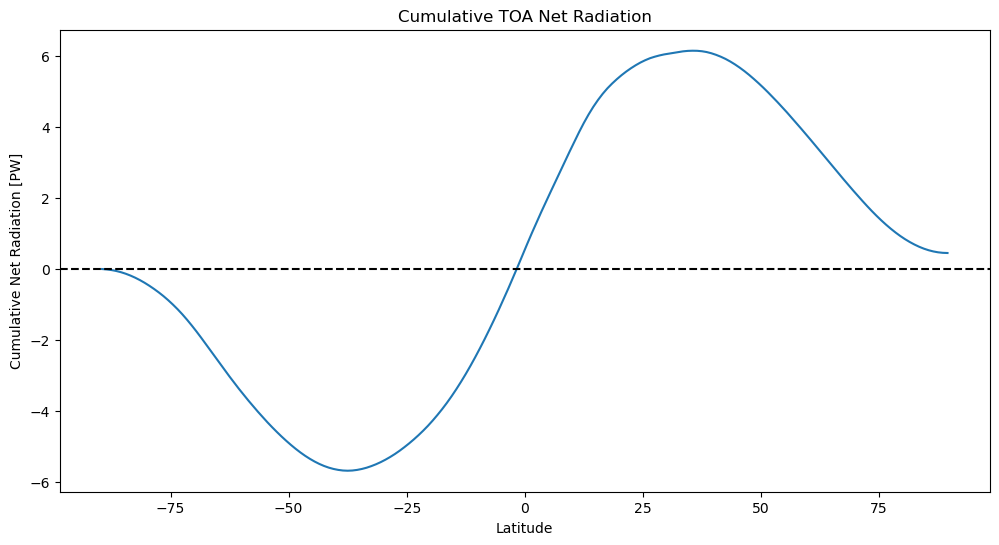

In [84]:
#4.3
# Cumulative sum
radiation_cumsum = radiation_per_lat.cumsum(dim='lat')

# 1 PW = 1e15 W
radiation_cumsum_PW = radiation_cumsum / 1e15

radiation_cumsum_PW.plot()
plt.xlabel('Latitude')
plt.ylabel('Cumulative Net Radiation [PW]')
plt.title('Cumulative TOA Net Radiation')
plt.axhline(0, color='k', linestyle='--')
plt.show()

5.2 Arctic Sea Ice

In [85]:
import cartopy
import cartopy.crs as ccrs
url = 'https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc'
fname = pooch.retrieve(url, known_hash='19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c')
ds_ice = xr.open_dataset(fname, drop_variables='melt_onset_day_seaice_conc_cdr')
ds_ice

<xarray.Dataset> Size: 4MB
Dimensions:                     (time: 1, ygrid: 332, xgrid: 316)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid                       (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                       (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    latitude                    (ygrid, xgrid) float64 839kB ...
    longitude                   (ygrid, xgrid) float64 839kB ...
Data variables:
    projection                  |S1 1B ...
    seaice_conc_cdr             (time, ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr    (time, ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr       (time, ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc  (time, ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
Attributes: (12/70)
    references:                             Comiso, J. C., and F. Nishio. 200...
    program:                                NOAA Climate Data Record Program
    cdr_variable:                           seaice_conc_cdr
    software_version_id:                    git@bitbucket.org:nsidc/seaice_cd...
    Metadata_Link:                          https://nsidc.org/api/dataset/met...
    product_version:                        v03r01
    ...                                     ...
    scaling_factor:                         1.0
    false_easting:                          0.0
    false_northing:                         0.0
    semimajor_radius:                       6378273.0
    semiminor_radius:                       6356889.449
    proj_units:                             meters

In [86]:
# projection info in attributes
print(ds_ice.attrs)
for var in ds_ice.data_vars:
    print(var, ds_ice[var].attrs)

{'references': 'Comiso, J. C., and F. Nishio. 2008. Trends in the Sea Ice Cover Using Enhanced and Compatible AMSR-E, SSM/I, and SMMR Data. Journal of Geophysical Research 113, C02S07, doi:10.1029/2007JC0043257. ; Comiso, J. C., D. Cavalieri, C. Parkinson, and P. Gloersen. 1997. Passive Microwave Algorithms for Sea Ice Concentrations: A Comparison of Two Techniques. Remote Sensing of the Environment 60(3):357-84. ; Comiso, J. C. 1984. Characteristics of Winter Sea Ice from Satellite Multispectral Microwave Observations. Journal of Geophysical Research 91(C1):975-94. ; Cavalieri, D. J., P. Gloersen, and W. J. Campbell. 1984. Determination of Sea Ice Parameters with the NIMBUS-7 SMMR. Journal of Geophysical Research 89(D4):5355-5369. ; Cavalieri, D. J., C. l. Parkinson, P. Gloersen, J. C. Comiso, and H. J. Zwally. 1999. Deriving Long-term Time Series of Sea Ice Cover from Satellite Passive-Microwave Multisensor Data Sets. Journal of Geophysical Research 104(7):\t15,803-15,814.', 'program

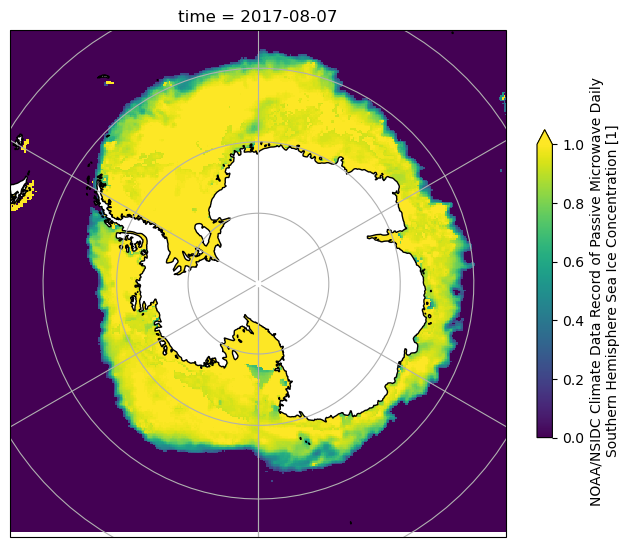

In [87]:
sic = ds_ice['seaice_conc_cdr'].isel(time=0)
sic = sic.where(sic >= 0)

data_crs = ccrs.SouthPolarStereo()

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=data_crs)
ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
ax.set_facecolor('white')

sic.plot(ax=ax, transform=data_crs, x='xgrid', y='ygrid',
         cmap='viridis', vmin=0, vmax=1,
         cbar_kwargs={'shrink': 0.5,
                      'label': 'NOAA/NSIDC Climate Data Record of Passive Microwave Daily\nSouthern Hemisphere Sea Ice Concentration [1]'})

ax.add_feature(cartopy.feature.LAND, facecolor='white', zorder=1)
ax.coastlines(zorder=2)
ax.gridlines()
ax.set_title('time = 2017-08-07')
plt.show()

5.3 Global USGS Earthquakes

In [88]:
import pandas as pd

eq_url = 'http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv'
df_eq = pd.read_csv(eq_url)
df_eq.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


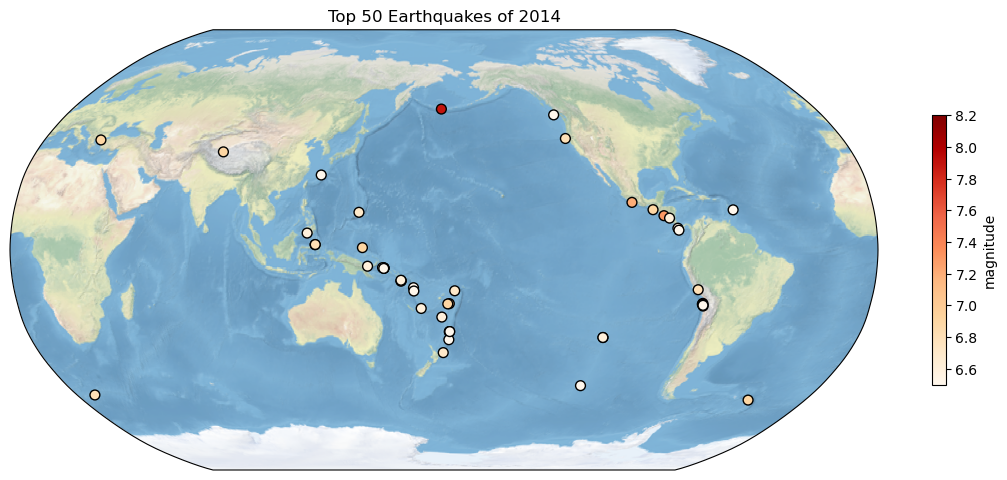

In [89]:
# Sort by magnitude and take top 50
df_top50 = df_eq.nlargest(50, 'mag')

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax.stock_img()

sc = ax.scatter(df_top50['longitude'], df_top50['latitude'],
                c=df_top50['mag'], cmap='OrRd',
                s=50, edgecolors='k',
                transform=ccrs.PlateCarree())

plt.colorbar(sc, label='magnitude', shrink=0.5)
ax.set_title('Top 50 Earthquakes of 2014')
plt.show()